# Gap-fill meteo variables

</br>

# Settings

## Data settings

In [1]:
SITE_LAT = 47.115833   # CH-FRU
SITE_LON = 8.537778  # CH-FRU
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)

## Imports

In [2]:
from datetime import datetime
import importlib.metadata
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
sns.set_theme('notebook')
import diive as dv
from diive.core.plotting.timeseries import TimeSeries
from diive.core.io.files import load_parquet, save_parquet
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.times.times import DetectFrequency
from diive.core.times.times import TimestampSanitizer
from diive.pkgs.createvar.potentialradiation import potrad
from diive.pkgs.corrections.offsetcorrection import remove_relativehumidity_offset, remove_radiation_zero_offset
from diive.pkgs.gapfilling.longterm import LongTermGapFillingXGBoostTS
from diive.pkgs.createvar.vpd import calc_vpd_from_ta_rh  # Used to calculate VPD
import warnings
from influxdb_client.client.warnings import MissingPivotFunction
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.87.0


</br>

# Load data from files

In [3]:
meteo = pd.read_csv("A2_TA_SWIN_RH_2023-2025.csv", index_col=0)
meteo.index = pd.to_datetime(meteo.index)
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1
TIMESTAMP_END,,,
2023-01-01 00:30:00,72.932509,0.0,9.115516
2023-01-01 01:00:00,72.409054,0.0,9.162511
2023-01-01 01:30:00,72.123254,0.0,9.665528
2023-01-01 02:00:00,74.133304,0.0,9.458139
2023-01-01 02:30:00,78.770632,0.0,8.713100
...,...,...,...
2025-12-31 22:00:00,95.027002,0.0,-8.169633
2025-12-31 22:30:00,95.338244,0.0,-8.388672
2025-12-31 23:00:00,92.821024,0.0,-8.424472


In [4]:
meteo.describe()

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1
count,51303.000000,52106.000000,51303.000000
mean,82.368362,140.196458,8.677823
std,17.124413,233.184247,7.647533
min,22.063927,0.000000,-11.849178
25%,71.083767,0.000000,3.188328
50%,87.182807,1.628152,8.283300
75%,97.616802,191.415504,14.185825
max,99.997990,1104.207108,31.666038


</br>

## Sanitize timestamp

In [5]:
meteo = TimestampSanitizer(data=meteo, output_middle_timestamp=True).get()
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1
TIMESTAMP_MIDDLE,,,
2023-01-01 00:15:00,72.932509,0.0,9.115516
2023-01-01 00:45:00,72.409054,0.0,9.162511
2023-01-01 01:15:00,72.123254,0.0,9.665528
2023-01-01 01:45:00,74.133304,0.0,9.458139
2023-01-01 02:15:00,78.770632,0.0,8.713100
...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633
2025-12-31 22:15:00,95.338244,0.0,-8.388672
2025-12-31 22:45:00,92.821024,0.0,-8.424472


</br>

# Gap-filling

## SW_IN_T1_1_1

### Target and features

In [6]:
TARGET = "SW_IN_T1_1_1"
subset = pd.DataFrame()
subset[TARGET] = meteo[[TARGET]].copy()
subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset

,SW_IN_T1_1_1,SW_IN_POT
TIMESTAMP_MIDDLE,,
2023-01-01 00:15:00,0.0,0.0
2023-01-01 00:45:00,0.0,0.0
2023-01-01 01:15:00,0.0,0.0
2023-01-01 01:45:00,0.0,0.0
2023-01-01 02:15:00,0.0,0.0
...,...,...
2025-12-31 21:45:00,0.0,0.0
2025-12-31 22:15:00,0.0,0.0
2025-12-31 22:45:00,0.0,0.0


### Initialize gap-filling

In [7]:
ltxgb = LongTermGapFillingXGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=0,
    # features_lag=[-1, -1],
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=True,
    perm_n_repeats=9,
    n_estimators=1000,
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=50,
    max_depth=6,
    # max_delta_step=0,
    # subsample=1,
    learning_rate=0.3,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy=0,
    grow_policy='lossguide',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 52608.


### Initialize yearly models

In [8]:
ltxgb.create_yearpools()
ltxgb.initialize_yearly_models()

[neighboring_years] Assigned [2023, 2024, 2025] to data pool for 2023.
[neighboring_years] Assigned [2023, 2024, 2025] to data pool for 2024.
[neighboring_years] Assigned [2023, 2024, 2025] to data pool for 2025.
Initializing model for 2023 ...
Initializing model for 2024 ...
Initializing model for 2025 ...


### Reduce features across years

In [9]:
ltxgb.reduce_features_across_years()

---
Reducing features based on permutation importance for year 2023 ...

[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:183.95073	validation_1-rmse:183.95073
[1]	validation_0-rmse:153.78400	validation_1-rmse:153.78400
[2]	validation_0-rmse:135.24059	validation_1-rmse:135.24059
[3]	validation_0-rmse:124.64858	validation_1-rmse:124.64858
[4]	validation_0-rmse:118.59368	validation_1-rmse:118.59368
[5]	validation_0-rmse:114.65651	validation_1-rmse:114.65651
[6]	validation_0-rmse:110.85166	validation_1-rmse:110.85166
[7]	validation_0-rmse:108.67785	validation_1-rmse:108.67785
[8]	validation_0-rmse:106.72323	validation_1-rmse:106.72323
[9]	validation_0-rmse:105.07126	validation_1-rmse:105.07126
[10]	validation_0-rmse:103.26969	validation_1-rmse:103.26969
[11]	validation_0-rmse:101.85038	validation_1-rmse:101.85038
[12]	validation_0-rmse:100.81313	validation_1-rmse:100.81313
[13]	validation_0-rmse:100.07520	validation_1-rmse:100.07520
[14]	va

### Train models and fill gaps

In [10]:
ltxgb.fillgaps()


Training model for 2023 ...

Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2023-01-01 00:15:00 and 2025-12-31 23:45:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:183.95858	validation_1-rmse:184.94032
[1]	validation_0-rmse:153.77114	validation_1-rmse:155.22576
[2]	validation_0-rmse:135.32606	validation_1-rmse:136.86580
[3]	validation_0-rmse:124.64435	validation_1-rmse:127.00664
[4]	validation_0-rmse:118.35113	validation_1-rmse:121.00359
[5]	validation_0-rmse:114.51290	validation_1-rmse:117.39692
[6]	validation_0-rmse:111.30858	validation_1-rmse:114.81938
[7]	validation_0-rmse:109.47552	validation_1-rmse:113.12943
[8]	validation_0-rmse:108.27654	validation_1-rmse:112.08857
[9]	validation_0-rmse:106.70117	validation_1-rmse:110.29020
[10]	validation_0-rmse:104.93467	validation_1-rmse:108.72985
[11]	validation_0-rmse:103.05035	validation_1-rmse:106.95972
[12]	validation_0-rmse:101.95989	validation_1-rmse:106.2

### Results: yearly scores

In [11]:
scores = pd.DataFrame(ltxgb.scores_)
scores.style.format("{:.4f}")

,2023,2024,2025
mae,28.9221,28.9221,28.9221
medae,7.3535,7.3535,7.3535
mse,3373.1232,3373.1232,3373.1232
rmse,58.0786,58.0786,58.0786
mape,8513126422333748.0000,8513126422333748.0000,8513126422333748.0000
maxe,785.9934,785.9934,785.9934
r2,0.9380,0.9380,0.9380


### Results: feature importances

In [12]:
ltxgb.feature_importances_yearly_

{'2023':                PERM_IMPORTANCE   PERM_SD
 SW_IN_POT             1.878665  0.014435
 .RECORDNUMBER         0.316156  0.003184
 .DOY_SIN              0.213721  0.002226
 .DOY_COS              0.192000  0.002528
 .YEARDOY              0.161907  0.001766
 .YEARWEEK             0.098482  0.001465
 .WEEK_SIN             0.084215  0.000920
 .WEEK_COS             0.041347  0.000457
 .YEARMONTH            0.012772  0.000534,
 '2024':                PERM_IMPORTANCE   PERM_SD
 SW_IN_POT             1.878665  0.014435
 .RECORDNUMBER         0.316156  0.003184
 .DOY_SIN              0.213721  0.002226
 .DOY_COS              0.192000  0.002528
 .YEARDOY              0.161907  0.001766
 .YEARWEEK             0.098482  0.001465
 .WEEK_SIN             0.084215  0.000920
 .WEEK_COS             0.041347  0.000457
 .YEARMONTH            0.012772  0.000534,
 '2025':                PERM_IMPORTANCE   PERM_SD
 SW_IN_POT             1.878665  0.014435
 .RECORDNUMBER         0.316156  0.003184
 .DOY_SI

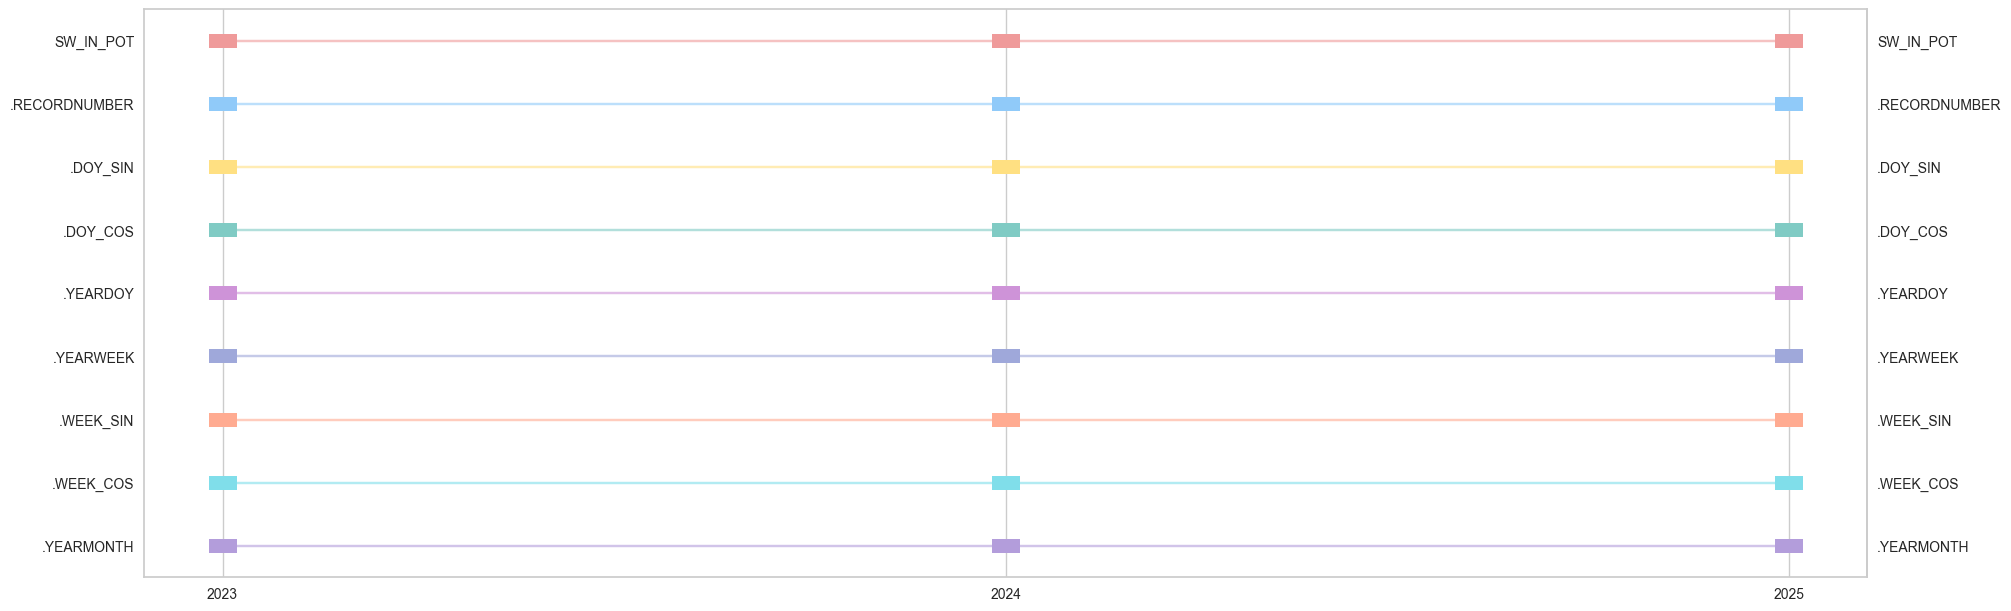

In [13]:
ltxgb.showplot_feature_ranks_per_year()

### Results: plot gap-filled time series

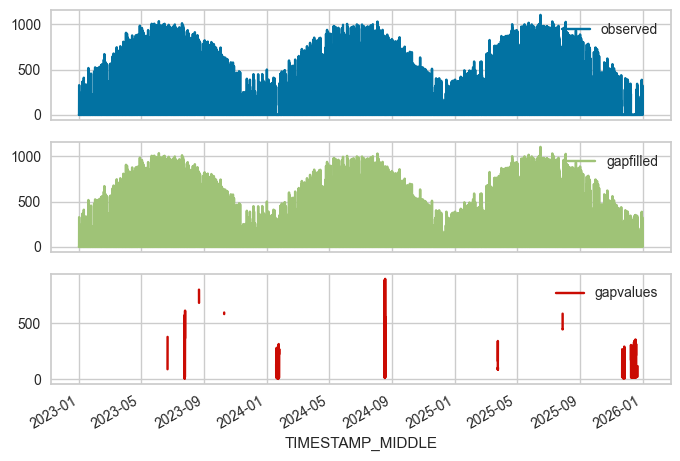

In [14]:
observed = subset[TARGET]
gapfilled = ltxgb.gapfilled_
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

### Add gap-filled series to dataframe

In [15]:
meteo[gapfilled.name] = gapfilled

### Plot time series

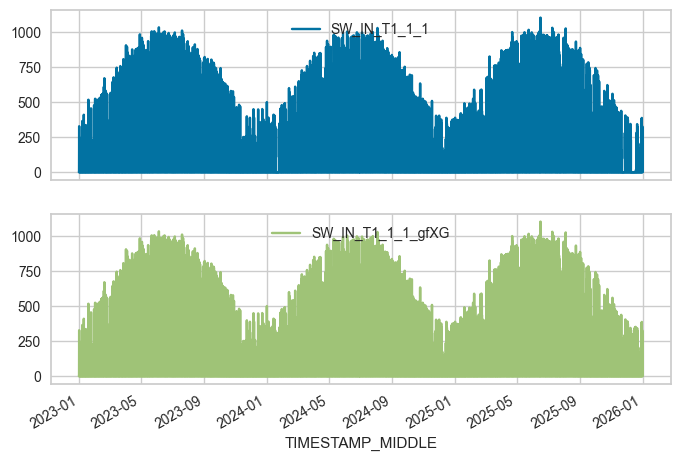

In [16]:
meteo[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

### Correction: Remove zero offset < 0 from `SW_IN_T1_47_1_gfXG`
- Additional correction needed because gap-filling introduced values < 0

In [17]:
meteo[[TARGET, gapfilled.name]].describe()

,SW_IN_T1_1_1,SW_IN_T1_1_1_gfXG
count,52106.000000,52608.000000
mean,140.196458,140.908971
std,233.184247,232.903409
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.628152,2.501760
75%,191.415504,193.858554
max,1104.207108,1104.207108


[remove_radiation_zero_offset]  running remove_radiation_zero_offset ...


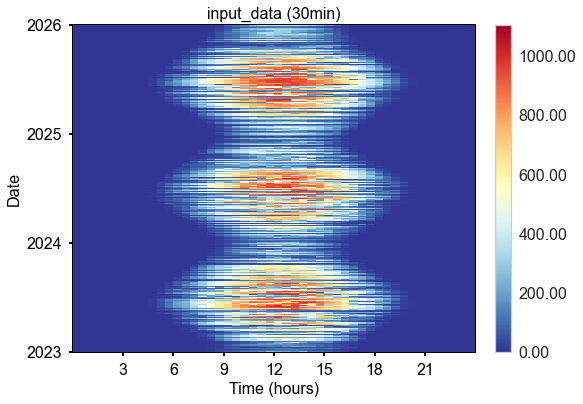

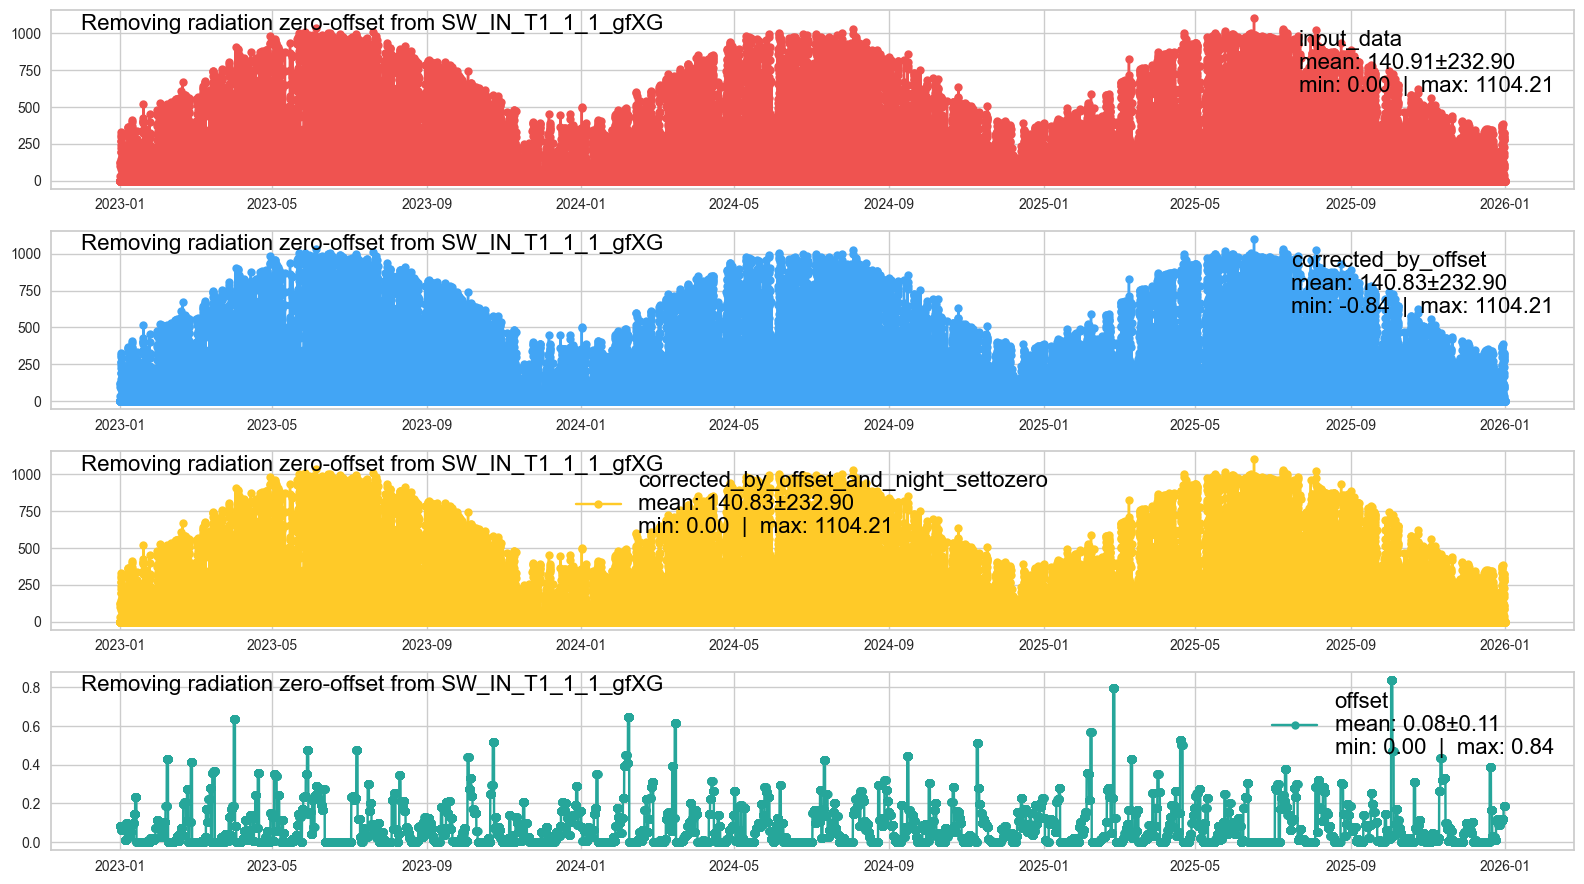

In [18]:
_swin = meteo['SW_IN_T1_1_1_gfXG'].copy()
_swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
meteo['SW_IN_T1_1_1_gfXG'] = np.nan
meteo['SW_IN_T1_1_1_gfXG'] = _swin_corrected

### Final dataframe

In [19]:
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG
TIMESTAMP_MIDDLE,,,,
2023-01-01 00:15:00,72.932509,0.0,9.115516,0.0
2023-01-01 00:45:00,72.409054,0.0,9.162511,0.0
2023-01-01 01:15:00,72.123254,0.0,9.665528,0.0
2023-01-01 01:45:00,74.133304,0.0,9.458139,0.0
2023-01-01 02:15:00,78.770632,0.0,8.713100,0.0
...,...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633,0.0
2025-12-31 22:15:00,95.338244,0.0,-8.388672,0.0
2025-12-31 22:45:00,92.821024,0.0,-8.424472,0.0


In [20]:
meteo.describe()

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG
count,51303.000000,52106.000000,51303.000000,52608.000000
mean,82.368362,140.196458,8.677823,140.826756
std,17.124413,233.184247,7.647533,232.896116
min,22.063927,0.000000,-11.849178,0.000000
25%,71.083767,0.000000,3.188328,0.000000
50%,87.182807,1.628152,8.283300,0.000000
75%,97.616802,191.415504,14.185825,193.787908
max,99.997990,1104.207108,31.666038,1104.207108


</br>

</br>

</br>

## TA_T1_2_1

### Target and features

In [21]:
TARGET = "TA_T1_2_1"
subset = pd.DataFrame()
subset[TARGET] = meteo[[TARGET]].copy()
subset['SW_IN_T1_1_1_gfXG'] = meteo['SW_IN_T1_1_1_gfXG'].copy()
# subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset

,TA_T1_2_1,SW_IN_T1_1_1_gfXG
TIMESTAMP_MIDDLE,,
2023-01-01 00:15:00,9.115516,0.0
2023-01-01 00:45:00,9.162511,0.0
2023-01-01 01:15:00,9.665528,0.0
2023-01-01 01:45:00,9.458139,0.0
2023-01-01 02:15:00,8.713100,0.0
...,...,...
2025-12-31 21:45:00,-8.169633,0.0
2025-12-31 22:15:00,-8.388672,0.0
2025-12-31 22:45:00,-8.424472,0.0


### Initialize gap-filling

In [22]:
ltxgb = LongTermGapFillingXGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=0,
    # features_lag=[-1, -1],
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=True,
    perm_n_repeats=9,
    n_estimators=1000,
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=50,
    max_depth=6,
    # max_delta_step=0,
    # subsample=1,
    learning_rate=0.3,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy=0,
    grow_policy='lossguide',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 52608.


### Initialize yearly models

In [23]:
ltxgb.create_yearpools()
ltxgb.initialize_yearly_models()

[neighboring_years] Assigned [2023, 2024, 2025] to data pool for 2023.
[neighboring_years] Assigned [2023, 2024, 2025] to data pool for 2024.
[neighboring_years] Assigned [2023, 2024, 2025] to data pool for 2025.
Initializing model for 2023 ...
Initializing model for 2024 ...
Initializing model for 2025 ...


### Reduce features across years

In [24]:
ltxgb.reduce_features_across_years()

---
Reducing features based on permutation importance for year 2023 ...

[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:5.95520	validation_1-rmse:5.95520
[1]	validation_0-rmse:4.87214	validation_1-rmse:4.87214
[2]	validation_0-rmse:4.17699	validation_1-rmse:4.17699
[3]	validation_0-rmse:3.74396	validation_1-rmse:3.74396
[4]	validation_0-rmse:3.44290	validation_1-rmse:3.44290
[5]	validation_0-rmse:3.23260	validation_1-rmse:3.23260
[6]	validation_0-rmse:3.03289	validation_1-rmse:3.03289
[7]	validation_0-rmse:2.93546	validation_1-rmse:2.93546
[8]	validation_0-rmse:2.86744	validation_1-rmse:2.86744
[9]	validation_0-rmse:2.80822	validation_1-rmse:2.80822
[10]	validation_0-rmse:2.74669	validation_1-rmse:2.74669
[11]	validation_0-rmse:2.71457	validation_1-rmse:2.71457
[12]	validation_0-rmse:2.69455	validation_1-rmse:2.69455
[13]	validation_0-rmse:2.64208	validation_1-rmse:2.64208
[14]	validation_0-rmse:2.57639	validation_1-rmse:2.57639
[15]	v

### Train models and fill gaps

In [25]:
ltxgb.fillgaps()


Training model for 2023 ...

Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2023-01-01 00:15:00 and 2025-12-31 23:45:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:5.95636	validation_1-rmse:5.92275
[1]	validation_0-rmse:4.87319	validation_1-rmse:4.85750
[2]	validation_0-rmse:4.17805	validation_1-rmse:4.17824
[3]	validation_0-rmse:3.74277	validation_1-rmse:3.75492
[4]	validation_0-rmse:3.44211	validation_1-rmse:3.46666
[5]	validation_0-rmse:3.21920	validation_1-rmse:3.24778
[6]	validation_0-rmse:3.08273	validation_1-rmse:3.11843
[7]	validation_0-rmse:3.01456	validation_1-rmse:3.05482
[8]	validation_0-rmse:2.92559	validation_1-rmse:2.96764
[9]	validation_0-rmse:2.85474	validation_1-rmse:2.89695
[10]	validation_0-rmse:2.81828	validation_1-rmse:2.86125
[11]	validation_0-rmse:2.74231	validation_1-rmse:2.78699
[12]	validation_0-rmse:2.70393	validation_1-rmse:2.75357
[13]	validation_0-rmse:2.67802	validation_1-rms

### Results: yearly scores

In [26]:
scores = pd.DataFrame(ltxgb.scores_)
scores.style.format("{:.4f}")

,2023,2024,2025
mae,0.3970,0.3970,0.3970
medae,0.2694,0.2694,0.2694
mse,0.3348,0.3348,0.3348
rmse,0.5786,0.5786,0.5786
mape,0.2707,0.2707,0.2707
maxe,7.3387,7.3387,7.3387
r2,0.9943,0.9943,0.9943


### Results: feature importances

In [27]:
ltxgb.feature_importances_yearly_

{'2023':                    PERM_IMPORTANCE   PERM_SD
 .DOY_COS                  1.053426  0.006112
 .DOY_SIN                  0.452742  0.003573
 .RECORDNUMBER             0.380136  0.002242
 .YEARDOY                  0.209630  0.001205
 SW_IN_T1_1_1_gfXG         0.109636  0.000784
 .YEARWEEK                 0.104567  0.000373
 .HOUR_SIN                 0.069339  0.000470
 .WEEK_SIN                 0.055814  0.000351
 .HOUR_COS                 0.036996  0.000276
 .WEEK_COS                 0.032904  0.000239
 .YEARMONTH                0.019066  0.000123
 .MONTH_SIN                0.007826  0.000063
 .YEAR                     0.000727  0.000015
 .SEASON_SIN               0.000329  0.000007,
 '2024':                    PERM_IMPORTANCE   PERM_SD
 .DOY_COS                  1.053426  0.006112
 .DOY_SIN                  0.452742  0.003573
 .RECORDNUMBER             0.380136  0.002242
 .YEARDOY                  0.209630  0.001205
 SW_IN_T1_1_1_gfXG         0.109636  0.000784
 .YEARWEEK       

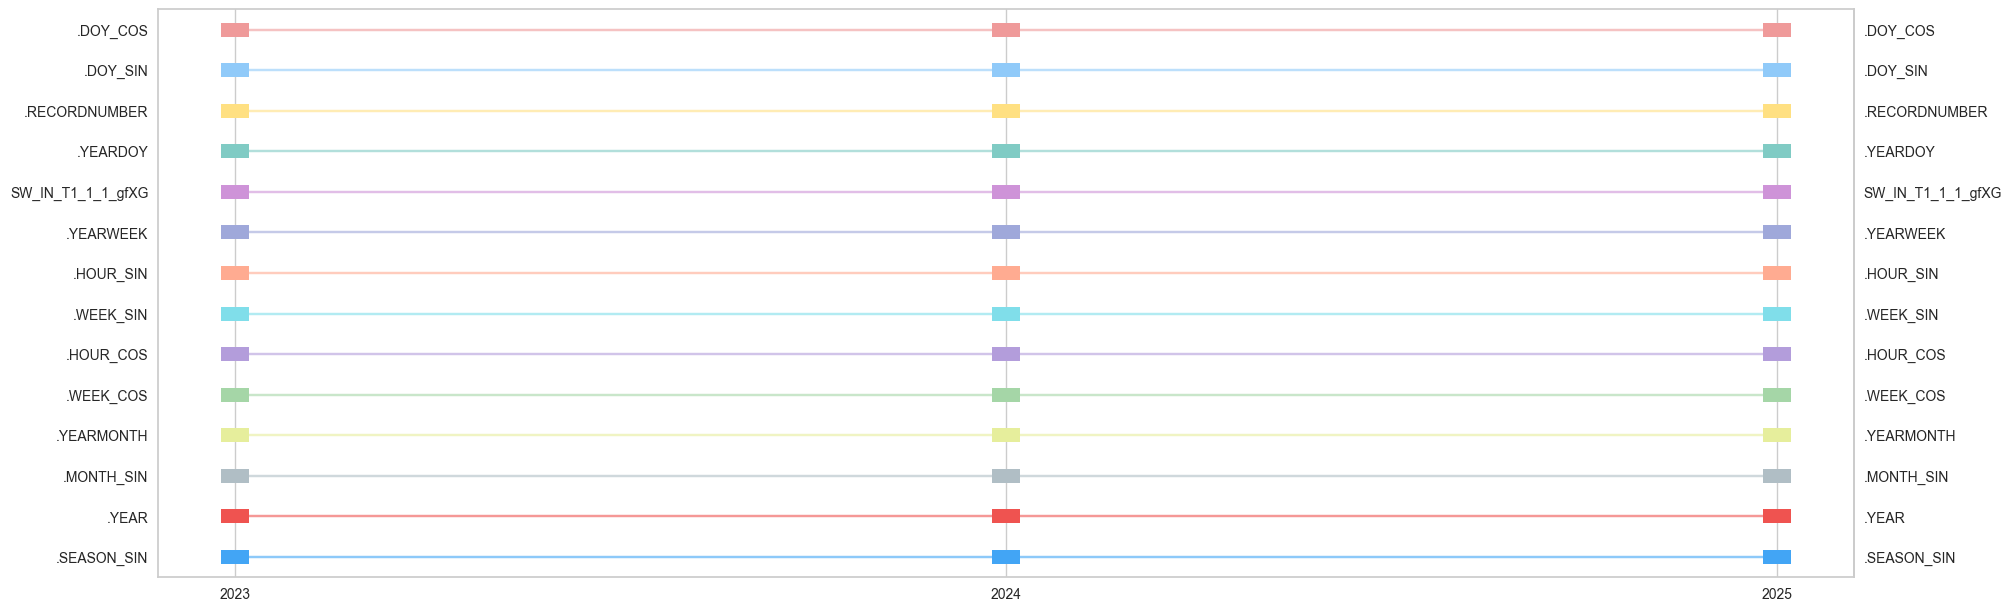

In [28]:
ltxgb.showplot_feature_ranks_per_year()

### Results: plot gap-filled time series

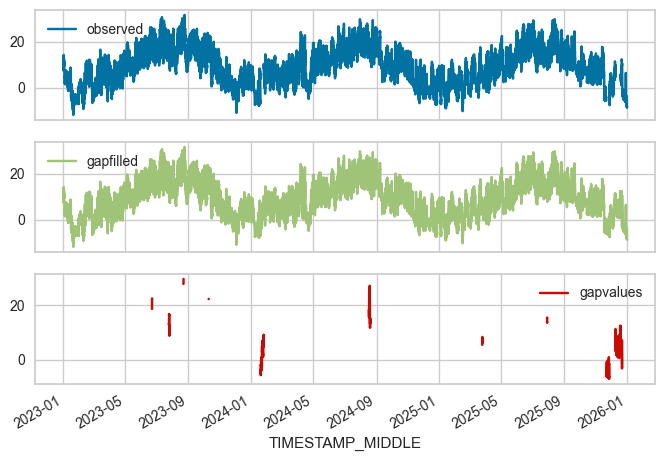

In [29]:
observed = subset[TARGET]
gapfilled = ltxgb.gapfilled_
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

### Add gap-filled series to dataframe

In [30]:
meteo[gapfilled.name] = gapfilled

### Plot time series

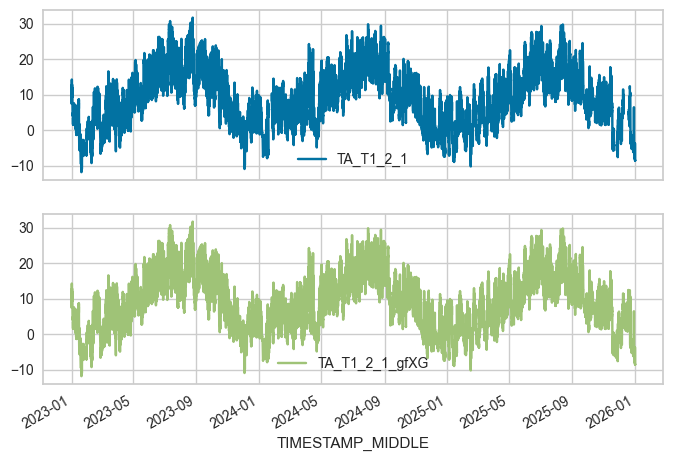

In [31]:
meteo[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

### Final dataframe

In [32]:
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG
TIMESTAMP_MIDDLE,,,,,
2023-01-01 00:15:00,72.932509,0.0,9.115516,0.0,9.115516
2023-01-01 00:45:00,72.409054,0.0,9.162511,0.0,9.162511
2023-01-01 01:15:00,72.123254,0.0,9.665528,0.0,9.665528
2023-01-01 01:45:00,74.133304,0.0,9.458139,0.0,9.458139
2023-01-01 02:15:00,78.770632,0.0,8.713100,0.0,8.713100
...,...,...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633,0.0,-8.169633
2025-12-31 22:15:00,95.338244,0.0,-8.388672,0.0,-8.388672
2025-12-31 22:45:00,92.821024,0.0,-8.424472,0.0,-8.424472


In [33]:
meteo.describe()

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG
count,51303.000000,52106.000000,51303.000000,52608.000000,52608.000000
mean,82.368362,140.196458,8.677823,140.826756,8.564649
std,17.124413,233.184247,7.647533,232.896116,7.675401
min,22.063927,0.000000,-11.849178,0.000000,-11.849178
25%,71.083767,0.000000,3.188328,0.000000,3.058919
50%,87.182807,1.628152,8.283300,0.000000,8.137444
75%,97.616802,191.415504,14.185825,193.787908,14.092709
max,99.997990,1104.207108,31.666038,1104.207108,31.666038


</br>

</br>

## VPD

### Calculate VPD

In [34]:
vpd = calc_vpd_from_ta_rh(df=meteo, ta_col='TA_T1_2_1', rh_col='RH_T1_2_1')
vpd

TIMESTAMP_MIDDLE
2023-01-01 00:15:00    0.313525
2023-01-01 00:45:00    0.320604
2023-01-01 01:15:00    0.335098
2023-01-01 01:45:00    0.306624
2023-01-01 02:15:00    0.239294
                         ...   
2025-12-31 21:45:00    0.016381
2025-12-31 22:15:00    0.015095
2025-12-31 22:45:00    0.023180
2025-12-31 23:15:00    0.024910
2025-12-31 23:45:00    0.031322
Freq: 30min, Name: VPD, Length: 52608, dtype: float64

In [35]:
meteo['VPD_T1_2_1'] = vpd.copy()
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG,VPD_T1_2_1
TIMESTAMP_MIDDLE,,,,,,
2023-01-01 00:15:00,72.932509,0.0,9.115516,0.0,9.115516,0.313525
2023-01-01 00:45:00,72.409054,0.0,9.162511,0.0,9.162511,0.320604
2023-01-01 01:15:00,72.123254,0.0,9.665528,0.0,9.665528,0.335098
2023-01-01 01:45:00,74.133304,0.0,9.458139,0.0,9.458139,0.306624
2023-01-01 02:15:00,78.770632,0.0,8.713100,0.0,8.713100,0.239294
...,...,...,...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633,0.0,-8.169633,0.016381
2025-12-31 22:15:00,95.338244,0.0,-8.388672,0.0,-8.388672,0.015095
2025-12-31 22:45:00,92.821024,0.0,-8.424472,0.0,-8.424472,0.023180


### Target and features

In [36]:
TARGET = "VPD_T1_2_1"
subset = pd.DataFrame()
subset[TARGET] = meteo[[TARGET]].copy()
subset['SW_IN_T1_1_1_gfXG'] = meteo['SW_IN_T1_1_1_gfXG'].copy()
subset['TA_T1_2_1_gfXG'] = meteo['TA_T1_2_1_gfXG'].copy()
subset

,VPD_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG
TIMESTAMP_MIDDLE,,,
2023-01-01 00:15:00,0.313525,0.0,9.115516
2023-01-01 00:45:00,0.320604,0.0,9.162511
2023-01-01 01:15:00,0.335098,0.0,9.665528
2023-01-01 01:45:00,0.306624,0.0,9.458139
2023-01-01 02:15:00,0.239294,0.0,8.713100
...,...,...,...
2025-12-31 21:45:00,0.016381,0.0,-8.169633
2025-12-31 22:15:00,0.015095,0.0,-8.388672
2025-12-31 22:45:00,0.023180,0.0,-8.424472


### Initialize gap-filling

In [37]:
ltxgb = LongTermGapFillingXGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=0,
    # features_lag=[-1, -1],
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=True,
    perm_n_repeats=9,
    n_estimators=1000,
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=50,
    max_depth=6,
    # max_delta_step=0,
    # subsample=1,
    learning_rate=0.3,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy=0,
    grow_policy='lossguide',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 52608.


### Initialize yearly models

In [38]:
ltxgb.create_yearpools()
ltxgb.initialize_yearly_models()

[neighboring_years] Assigned [2023, 2024, 2025] to data pool for 2023.
[neighboring_years] Assigned [2023, 2024, 2025] to data pool for 2024.
[neighboring_years] Assigned [2023, 2024, 2025] to data pool for 2025.
Initializing model for 2023 ...
Initializing model for 2024 ...
Initializing model for 2025 ...


### Reduce features across years

In [39]:
ltxgb.reduce_features_across_years()

---
Reducing features based on permutation importance for year 2023 ...

[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:0.27875	validation_1-rmse:0.27875
[1]	validation_0-rmse:0.22131	validation_1-rmse:0.22131
[2]	validation_0-rmse:0.18334	validation_1-rmse:0.18334
[3]	validation_0-rmse:0.15865	validation_1-rmse:0.15865
[4]	validation_0-rmse:0.14288	validation_1-rmse:0.14288
[5]	validation_0-rmse:0.13364	validation_1-rmse:0.13364
[6]	validation_0-rmse:0.12786	validation_1-rmse:0.12786
[7]	validation_0-rmse:0.12322	validation_1-rmse:0.12322
[8]	validation_0-rmse:0.11943	validation_1-rmse:0.11943
[9]	validation_0-rmse:0.11671	validation_1-rmse:0.11671
[10]	validation_0-rmse:0.11446	validation_1-rmse:0.11446
[11]	validation_0-rmse:0.11104	validation_1-rmse:0.11104
[12]	validation_0-rmse:0.10946	validation_1-rmse:0.10946
[13]	validation_0-rmse:0.10795	validation_1-rmse:0.10795
[14]	validation_0-rmse:0.10631	validation_1-rmse:0.10631
[15]	v

### Train models and fill gaps

In [40]:
ltxgb.fillgaps()


Training model for 2023 ...

Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2023-01-01 00:15:00 and 2025-12-31 23:45:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:0.27875	validation_1-rmse:0.28047
[1]	validation_0-rmse:0.22131	validation_1-rmse:0.22300
[2]	validation_0-rmse:0.18335	validation_1-rmse:0.18481
[3]	validation_0-rmse:0.15870	validation_1-rmse:0.16011
[4]	validation_0-rmse:0.14291	validation_1-rmse:0.14502
[5]	validation_0-rmse:0.13368	validation_1-rmse:0.13619
[6]	validation_0-rmse:0.12789	validation_1-rmse:0.13080
[7]	validation_0-rmse:0.12321	validation_1-rmse:0.12624
[8]	validation_0-rmse:0.11952	validation_1-rmse:0.12276
[9]	validation_0-rmse:0.11712	validation_1-rmse:0.12086
[10]	validation_0-rmse:0.11502	validation_1-rmse:0.11931
[11]	validation_0-rmse:0.11156	validation_1-rmse:0.11617
[12]	validation_0-rmse:0.10994	validation_1-rmse:0.11466
[13]	validation_0-rmse:0.10870	validation_1-rms

### Results: yearly scores

In [41]:
scores = pd.DataFrame(ltxgb.scores_)
scores.style.format("{:.4f}")

,2023,2024,2025
mae,0.0169,0.0169,0.0169
medae,0.0097,0.0097,0.0097
mse,0.0008,0.0008,0.0008
rmse,0.0291,0.0291,0.0291
mape,58.1374,58.1374,58.1374
maxe,0.4943,0.4943,0.4943
r2,0.9937,0.9937,0.9937


### Results: feature importances

In [42]:
ltxgb.feature_importances_yearly_

{'2023':                    PERM_IMPORTANCE   PERM_SD
 TA_T1_2_1_gfXG            3.537128  0.016235
 .DOY_COS                  0.534411  0.003910
 .DOY_SIN                  0.199476  0.001639
 .RECORDNUMBER             0.152404  0.000969
 .YEARDOY                  0.135245  0.000493
 .YEARWEEK                 0.046957  0.000419
 SW_IN_T1_1_1_gfXG         0.042620  0.000572
 .HOUR_COS                 0.036204  0.000215
 .WEEK_COS                 0.033542  0.000197
 .WEEK_SIN                 0.030768  0.000218
 .HOUR_SIN                 0.020700  0.000290
 .MONTH_SIN                0.010820  0.000127
 .SEASON_COS               0.009567  0.000091
 .YEARMONTH                0.005545  0.000073
 .MONTH_COS                0.002953  0.000041,
 '2024':                    PERM_IMPORTANCE   PERM_SD
 TA_T1_2_1_gfXG            3.537128  0.016235
 .DOY_COS                  0.534411  0.003910
 .DOY_SIN                  0.199476  0.001639
 .RECORDNUMBER             0.152404  0.000969
 .YEARDOY        

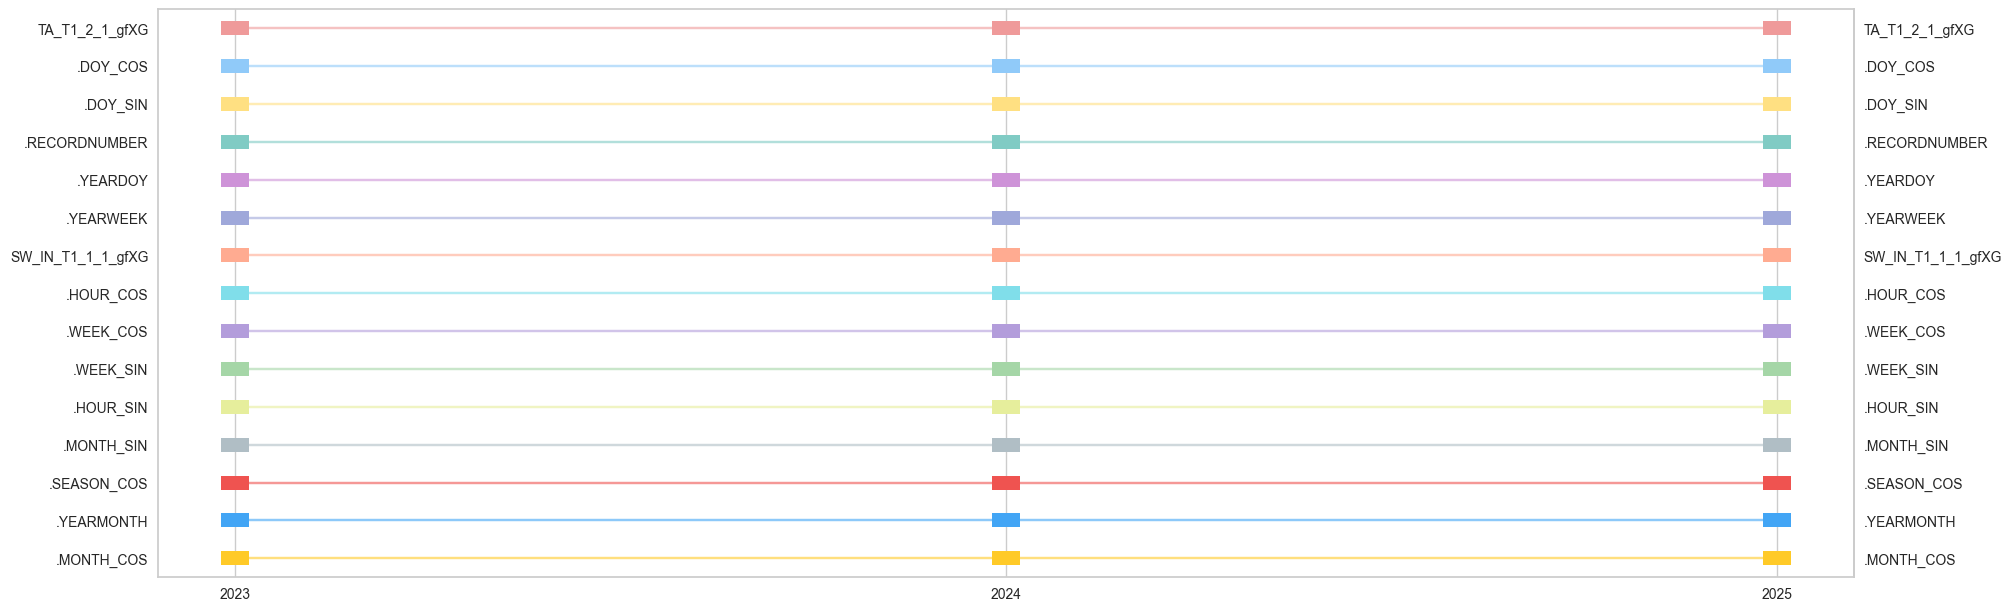

In [43]:
ltxgb.showplot_feature_ranks_per_year()

### Results: plot gap-filled time series

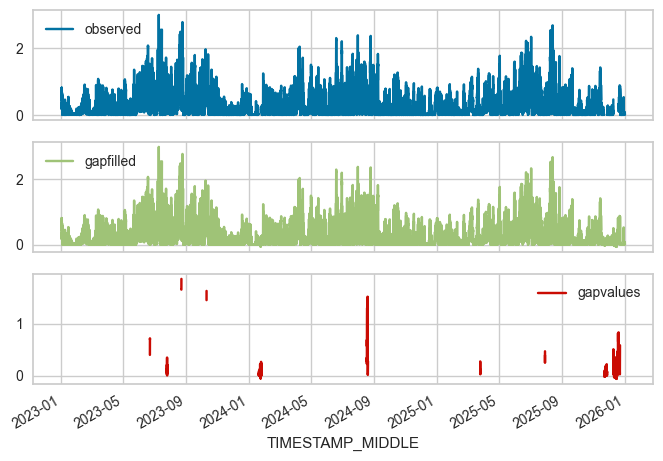

In [44]:
observed = subset[TARGET]
gapfilled = ltxgb.gapfilled_
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

### Add gap-filled series to dataframe

In [45]:
meteo[gapfilled.name] = gapfilled

### Plot time series

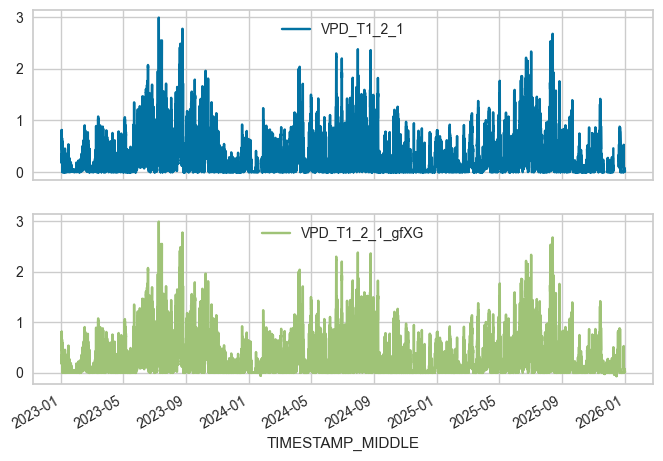

In [46]:
meteo[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

### Set values < 0 to minimum

In [47]:
smallest_positive_vpd = meteo[gapfilled.name][meteo[gapfilled.name] > 0].min()
smallest_positive_vpd

np.float64(8.270101659411746e-06)

In [48]:
vpd_minimum = meteo[gapfilled.name].min()
print(f"Gap-filled VPD minimum before correction: {vpd_minimum}")
meteo[gapfilled.name].loc[meteo[gapfilled.name] < 0] = smallest_positive_vpd
vpd_minimum = meteo[gapfilled.name].min()
print(f"Gap-filled VPD minimum after correction: {vpd_minimum}")

Gap-filled VPD minimum before correction: -0.06514573842287064
Gap-filled VPD minimum after correction: 8.270101659411746e-06


### Final dataframe

In [49]:
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG,VPD_T1_2_1,VPD_T1_2_1_gfXG
TIMESTAMP_MIDDLE,,,,,,,
2023-01-01 00:15:00,72.932509,0.0,9.115516,0.0,9.115516,0.313525,0.313525
2023-01-01 00:45:00,72.409054,0.0,9.162511,0.0,9.162511,0.320604,0.320604
2023-01-01 01:15:00,72.123254,0.0,9.665528,0.0,9.665528,0.335098,0.335098
2023-01-01 01:45:00,74.133304,0.0,9.458139,0.0,9.458139,0.306624,0.306624
2023-01-01 02:15:00,78.770632,0.0,8.713100,0.0,8.713100,0.239294,0.239294
...,...,...,...,...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633,0.0,-8.169633,0.016381,0.016381
2025-12-31 22:15:00,95.338244,0.0,-8.388672,0.0,-8.388672,0.015095,0.015095
2025-12-31 22:45:00,92.821024,0.0,-8.424472,0.0,-8.424472,0.023180,0.023180


In [50]:
meteo.describe()

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG,VPD_T1_2_1,VPD_T1_2_1_gfXG
count,51303.000000,52106.000000,51303.000000,52608.000000,52608.000000,51303.000000,52608.000000
mean,82.368362,140.196458,8.677823,140.826756,8.564649,0.280849,0.277760
std,17.124413,233.184247,7.647533,232.896116,7.675401,0.367271,0.365614
min,22.063927,0.000000,-11.849178,0.000000,-11.849178,0.000008,0.000008
25%,71.083767,0.000000,3.188328,0.000000,3.058919,0.018669,0.018648
50%,87.182807,1.628152,8.283300,0.000000,8.137444,0.134936,0.131118
75%,97.616802,191.415504,14.185825,193.787908,14.092709,0.404866,0.398127
max,99.997990,1104.207108,31.666038,1104.207108,31.666038,2.989822,2.989822


</br>

</br>

# Plot time series

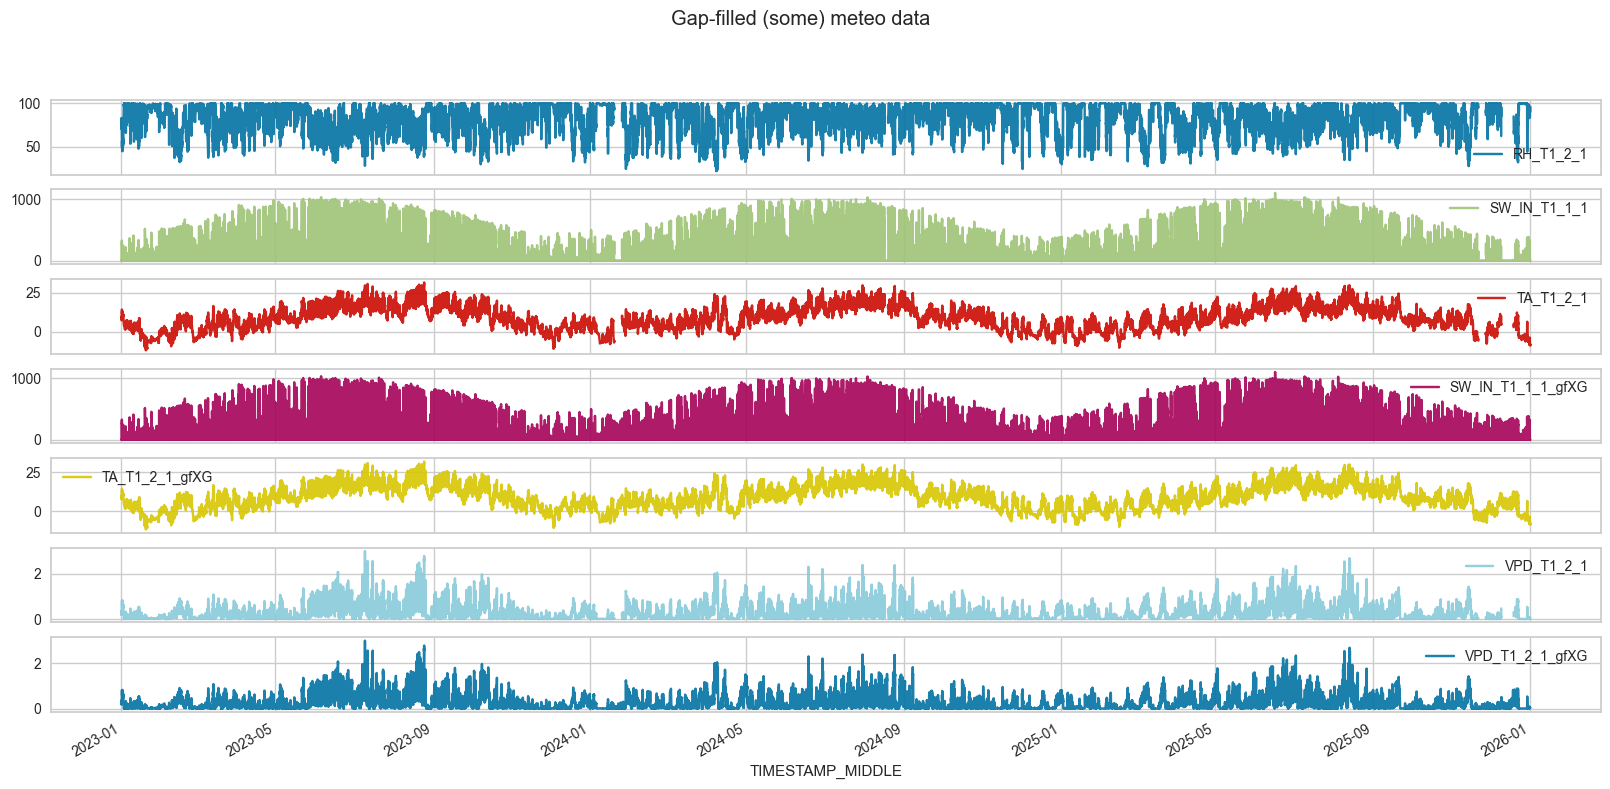

In [51]:
_plot_df = meteo.copy()
_plot_df = _plot_df.replace(-9999, np.nan)
_plot_df.plot(subplots=True, figsize=(20, 9), title="Gap-filled (some) meteo data", alpha=.9, x_compat=True);

# Plot heatmaps

In [52]:
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG,VPD_T1_2_1,VPD_T1_2_1_gfXG
TIMESTAMP_MIDDLE,,,,,,,
2023-01-01 00:15:00,72.932509,0.0,9.115516,0.0,9.115516,0.313525,0.313525
2023-01-01 00:45:00,72.409054,0.0,9.162511,0.0,9.162511,0.320604,0.320604
2023-01-01 01:15:00,72.123254,0.0,9.665528,0.0,9.665528,0.335098,0.335098
2023-01-01 01:45:00,74.133304,0.0,9.458139,0.0,9.458139,0.306624,0.306624
2023-01-01 02:15:00,78.770632,0.0,8.713100,0.0,8.713100,0.239294,0.239294
...,...,...,...,...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633,0.0,-8.169633,0.016381,0.016381
2025-12-31 22:15:00,95.338244,0.0,-8.388672,0.0,-8.388672,0.015095,0.015095
2025-12-31 22:45:00,92.821024,0.0,-8.424472,0.0,-8.424472,0.023180,0.023180


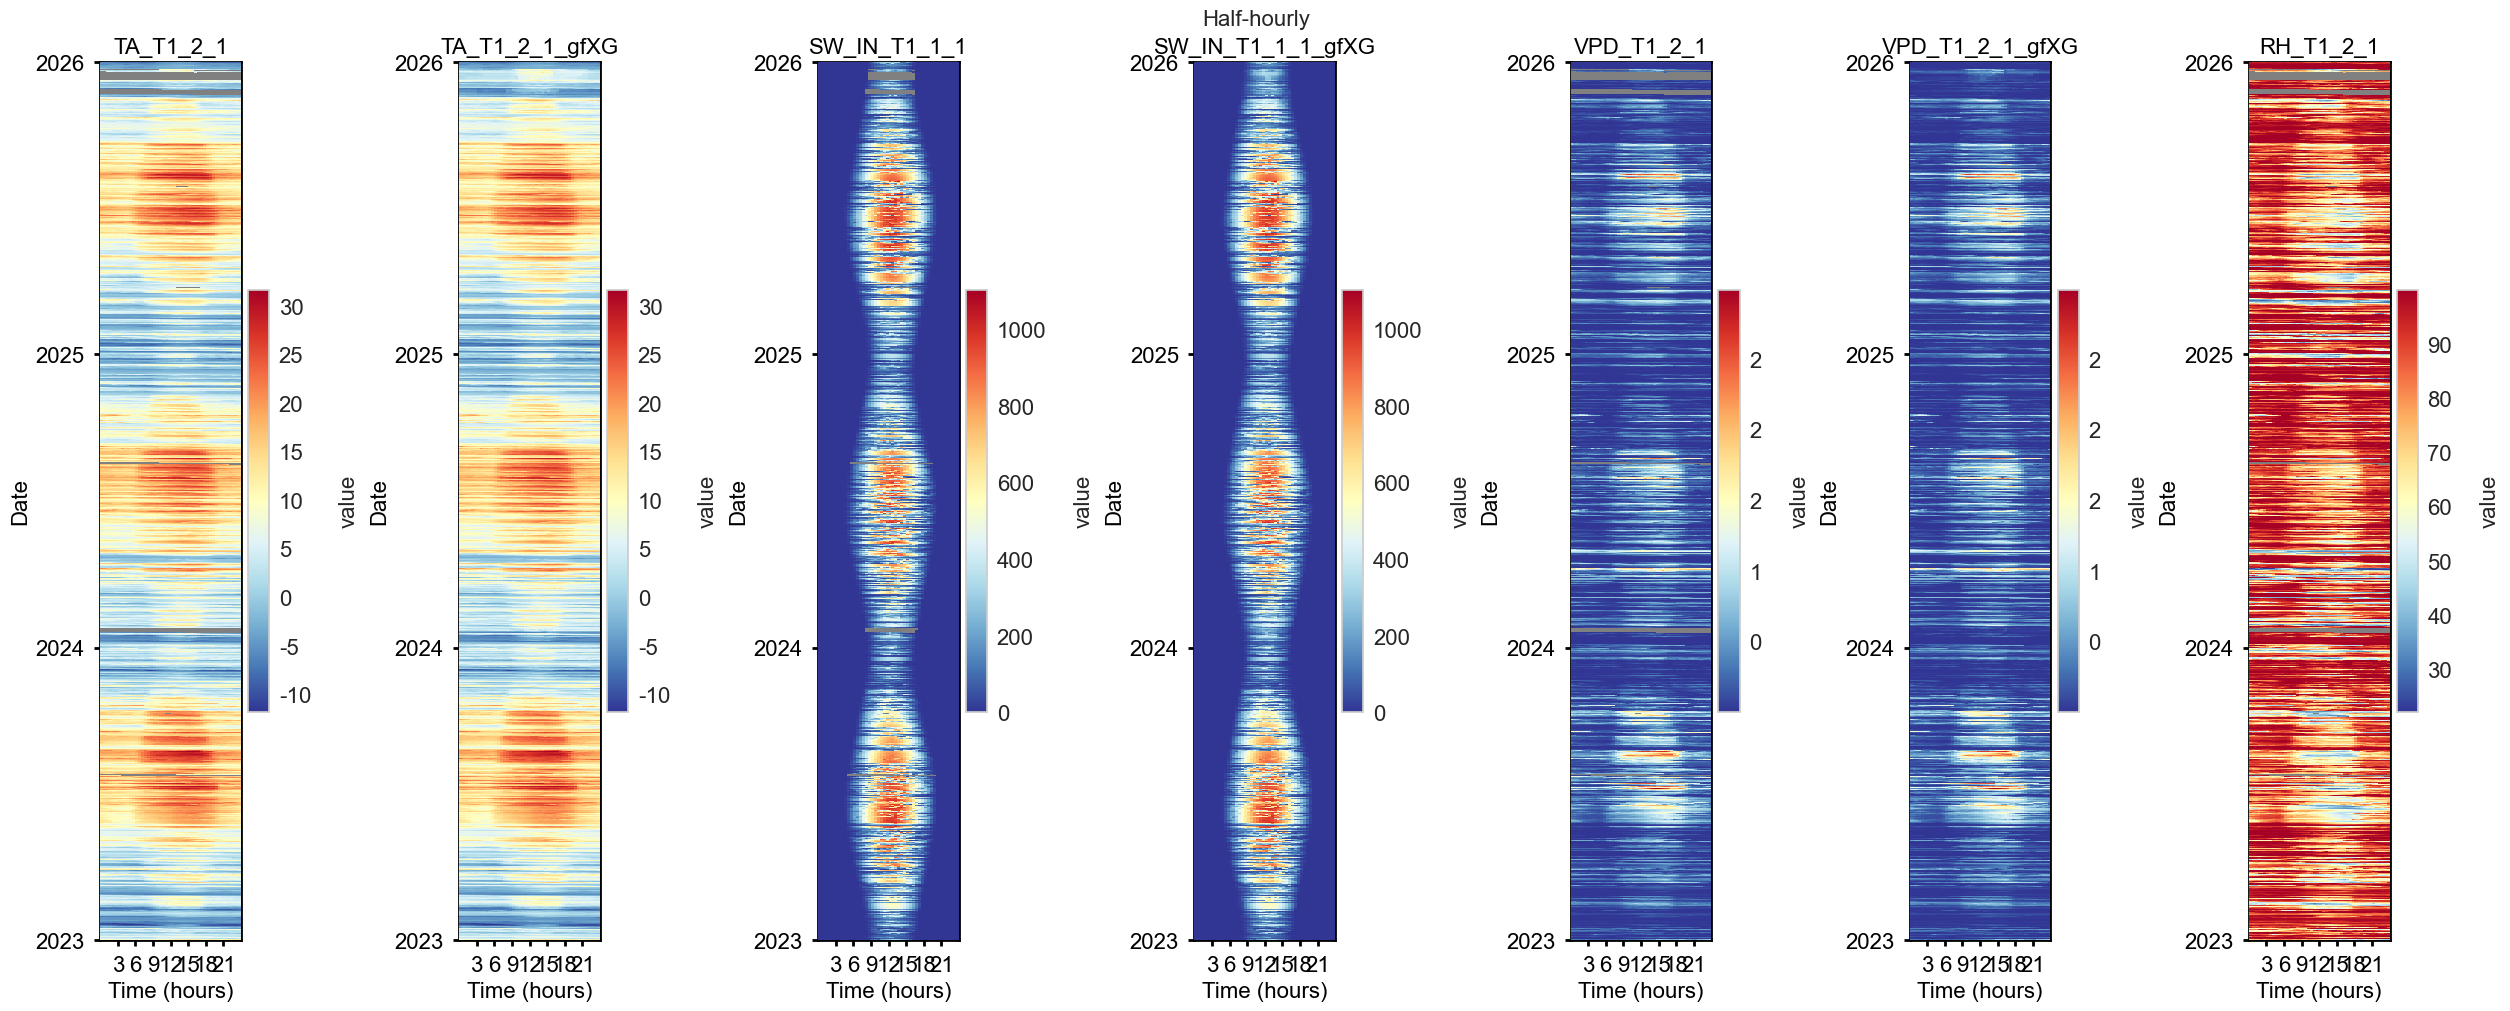

In [53]:
fig, axs = plt.subplots(ncols=7, figsize=(25, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=meteo['TA_T1_2_1'], title="TA_T1_2_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['TA_T1_2_1_gfXG'], title="TA_T1_2_1_gfXG", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['SW_IN_T1_1_1'], title="SW_IN_T1_1_1", ax=axs[2], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['SW_IN_T1_1_1_gfXG'], title="SW_IN_T1_1_1_gfXG", ax=axs[3], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['VPD_T1_2_1'], title="VPD_T1_2_1", ax=axs[4], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['VPD_T1_2_1_gfXG'], title="VPD_T1_2_1_gfXG", ax=axs[5], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['RH_T1_2_1'], title="RH_T1_2_1", ax=axs[6], cb_digits_after_comma=0, zlabel="value").plot()

</br>

# Stats

In [54]:
meteo.describe()

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG,VPD_T1_2_1,VPD_T1_2_1_gfXG
count,51303.000000,52106.000000,51303.000000,52608.000000,52608.000000,51303.000000,52608.000000
mean,82.368362,140.196458,8.677823,140.826756,8.564649,0.280849,0.277760
std,17.124413,233.184247,7.647533,232.896116,7.675401,0.367271,0.365614
min,22.063927,0.000000,-11.849178,0.000000,-11.849178,0.000008,0.000008
25%,71.083767,0.000000,3.188328,0.000000,3.058919,0.018669,0.018648
50%,87.182807,1.628152,8.283300,0.000000,8.137444,0.134936,0.131118
75%,97.616802,191.415504,14.185825,193.787908,14.092709,0.404866,0.398127
max,99.997990,1104.207108,31.666038,1104.207108,31.666038,2.989822,2.989822


</br>

# Save to file

In [55]:
OUTNAME = "A4_METEO4_GAPFILLED_2023-2025"
OUTPATH = r""
# filepath = save_parquet(filename=OUTNAME, data=meteo6_2004_2025, outpath=OUTPATH)
meteo.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")

</br>

# End of notebook.

In [56]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-01-26 16:24:24


</br>